# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../../lectures/lecture01/lecture01.md), [демо](../../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ.** Пусть $p=(1,2,3)^\top$, а $x=(x_1,x_2,x_3)\in\mathbb R^3$ — искомая точка. Квадрат расстояния удобно минимизировать вместо самого расстояния:

$$f(x)=\frac12\|x-p\|_2^2,\qquad
g(x)=\begin{pmatrix}x_1+x_2+x_3-1\\x_1-x_3\end{pmatrix}=0.$$

Неравенств $h$ нет. Это выпуклая QP с линейными равенствами: $\nabla^2 f=I\succ0$, а допустимое множество — прямая. Из равенств $x=(u,1-2u,u)$, поэтому $\|x-p\|_2^2=6u^2-4u+11$. Минимум при $u=1/3$, значит $x^*=(1/3,1/3,1/3)$; расстояние равно $\sqrt{31/3}$.

In [2]:
x_star = np.array([1/3, 1/3, 1/3])
p = np.array([1.0, 2.0, 3.0])
print("Ближайшая точка:", x_star)
print("Расстояние:", np.linalg.norm(x_star - p))

Ближайшая точка: [0.33333333 0.33333333 0.33333333]
Расстояние: 3.2145502536643185


**(б)**

**Ответ.** Переменная $x\in\mathbb R^n$ — количества продуктов ($x_j\ge0$). При $c\in\mathbb R^n$, $A\in\mathbb R^{m\times n}$, $b\in\mathbb R^m$:

$$f(x)=c^\top x,\qquad g\text{ отсутствует},\qquad
h(x)=\begin{pmatrix}Ax-b\\x\end{pmatrix}\ge0.$$

Это **LP с линейными неравенствами**, выпуклая задача: целевая функция линейна, а допустимое множество — пересечение полупространств.

**(в)**

**Ответ.** Пусть $x=(u,v)\in\mathbb R^2$, где $u,v\ge0$ — половины сторон прямоугольника. Его вершины — $(\pm u,\pm v)$, а площадь равна $4uv$. Для вписанного прямоугольника вершины лежат на окружности, поэтому

$$f(x)=-4uv,\qquad g(x)=u^2+v^2-1=0,\qquad
h(x)=\begin{pmatrix}u\\v\end{pmatrix}\ge0.$$

Это QCQP с ограничениями. В такой записи задача невыпуклая: дуга $u^2+v^2=1$ в первом квадранте не является выпуклым множеством; у цели гессиан с собственными значениями $4$ и $-4$. Из $2uv\le u^2+v^2=1$ следует $u=v=1/\sqrt2$: максимальная площадь равна $2$.

**(г)**

**Ответ.** Переменная $x=(x_1,x_2,x_3)\in\mathbb R^3$ задаёт амплитуду, частоту и фазу. При невязках $r_i(x)=x_1\sin(x_2t_i+x_3)-y_i$ получаем

$$f(x)=\sum_{i=1}^N r_i(x)^2,\qquad g,h\text{ отсутствуют}.$$

Это NLP без ограничений (нелинейный МНК). В общем случае задача невыпуклая: при изменении частоты и фазы синус даёт несколько минимумов; в частности, зависимость от фазы периодическая.

**(д, бонус)**

**Ответ (бонус).** Введём одну переменную $s\in\mathbb R$ и обозначим $z=(x,s)\in\mathbb R^{n+1}$. Задача принимает вид

$$\min_{x,s}\ s\quad\text{при}\quad
s-(a_i^\top x-b_i)\ge0,\qquad
s+(a_i^\top x-b_i)\ge0,\quad i=1,\ldots,m.$$

Здесь $f(z)=s$, равенств $g$ нет, а $h(z)$ состоит из этих $2m$ неравенств. Вместе они означают $s\ge |a_i^\top x-b_i|$ для каждого $i$; минимизация делает $s$ равным наибольшей абсолютной невязке. Цель и ограничения линейны, поэтому это выпуклая LP.

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

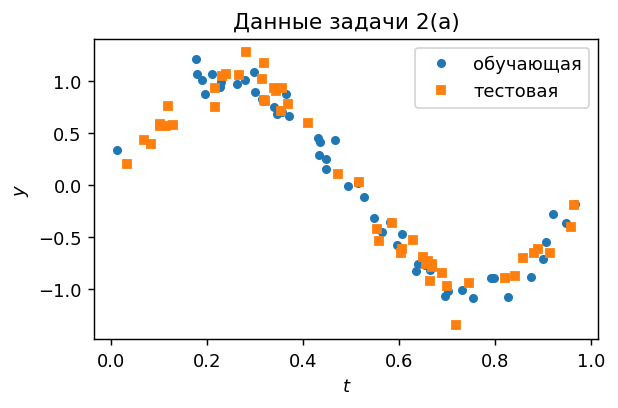

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

Минимальная тестовая MSE: 0.025973 при d=5


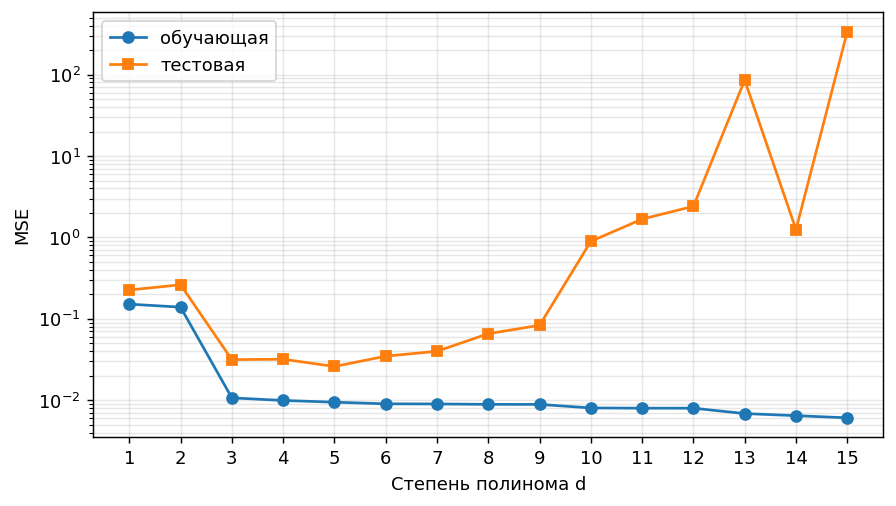

In [4]:
degrees = np.arange(1, 16)
mse_train, mse_test = [], []

for d in degrees:
    A_train = np.vander(t_train, d + 1, increasing=True)
    A_test = np.vander(t_test, d + 1, increasing=True)
    coef, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)
    mse_train.append(np.mean((A_train @ coef - y_train)**2))
    mse_test.append(np.mean((A_test @ coef - y_test)**2))

print(f"Минимальная тестовая MSE: {min(mse_test):.6f} при d={degrees[np.argmin(mse_test)]}")

plt.figure(figsize=(7, 4))
plt.semilogy(degrees, mse_train, "o-", label="обучающая")
plt.semilogy(degrees, mse_test, "s-", label="тестовая")
plt.xticks(degrees)
plt.xlabel("Степень полинома d")
plt.ylabel("MSE")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Ответ.** Обучающая MSE не возрастает: полином степени $d+1$ может повторить решение для степени $d$, если положить новый коэффициент равным нулю. Тестовая ошибка не минимизируется при подборе коэффициентов и потому меняется неровно. На этих данных её минимум при $d=5$; при больших степенях полином подгоняет шум обучающей выборки, а степенной базис становится плохо обусловленным.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
tol = 1e-9

def solve_diet(requirements):
    result = linprog(c, A_ub=-A, b_ub=-requirements,
                     bounds=(0, None), method="highs")
    if not result.success:
        raise RuntimeError(result.message)
    active_A = np.flatnonzero(np.abs(A @ result.x - requirements) <= tol) + 1
    active_x = np.flatnonzero(np.abs(result.x) <= tol) + 1
    return result, active_A, active_x

initial, initial_A, initial_x = solve_diet(b)
b_new = b.copy()
b_new[0] += 1
changed, changed_A, changed_x = solve_diet(b_new)

for label, result, nutrients, products in (
    ("Исходная задача", initial, initial_A, initial_x),
    ("После изменения b1", changed, changed_A, changed_x),
):
    print(label)
    print("  x =", result.x, "стоимость =", result.fun)
    print("  активны ограничения Ax >= b:", nutrients.tolist())
    print("  активны ограничения x >= 0:", products.tolist())

print("Изменение стоимости:", changed.fun - initial.fun)

Исходная задача
  x = [ 2.  4. -0.  0.] стоимость = 16.0
  активны ограничения Ax >= b: [1, 2, 3]
  активны ограничения x >= 0: [3, 4]
После изменения b1
  x = [1.88888889 3.55555556 0.         0.66666667] стоимость = 17.11111111111111
  активны ограничения Ax >= b: [1, 2, 3]
  активны ограничения x >= 0: [3]
Изменение стоимости: 1.1111111111111107


**Ответ.** Сначала $x^*=(2,4,0,0)$, стоимость $16$. Все три ограничения $Ax\ge b$ активны; среди $x_j\ge0$ активны $x_3=0$ и $x_4=0$.

После увеличения $b_1$ до $11$ решение равно $(17/9,32/9,0,2/3)$, стоимость — $154/9\approx17.1111$ (рост на $10/9$). Питательные ограничения по-прежнему активны все три, но из ограничений неотрицательности осталось активным только $x_3=0$: четвёртый продукт теперь покупается.